# Tarea 1 Por Juan Pablo Ramirez

## Punto uno

$$
\begin{aligned}
&\text{Se cumple la identidad:} \\
&\quad \text{rms}^2_w(x) = \text{avg}^2_w(x) + \text{std}^2_w(x) \\
\\
&\text{donde } w_1, w_2, \ldots, w_n \text{ son pesos positivos tales que la suma total de los pesos es:} \\
&\quad W = \sum_{i=1}^n w_i > 0 \\
\\
&\text{y donde tenemos las definiciones:} \\
&\quad \text{avg}_w(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i \\
&\quad \text{std}^2_w(x) = \frac{1}{W} \sum_{i=1}^n w_i \left(x_i - \text{avg}_w(x)\right)^2 \\
&\quad \text{rms}_w(x) = \sqrt{ \frac{1}{W} \sum_{i=1}^n w_i x_i^2 }
\end{aligned}
$$

$$
\begin{aligned}
&\text{Entonces:} \\
&\text{rms}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i^2 \\
&\text{Además, expandiendo:} \\
&\text{std}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i (x_i - \text{avg}_w(x))^2 \\
&= \frac{1}{W} \sum_{i=1}^n w_i \left( x_i^2 - 2x_i \text{avg}_w(x) + \text{avg}_w^2(x) \right) \\
&= \frac{1}{W} \left( \sum_{i=1}^n w_i x_i^2 - 2 \text{avg}_w(x) \sum_{i=1}^n w_i x_i + \text{avg}_w^2(x) \sum_{i=1}^n w_i \right) \\
&= \frac{1}{W} \left( \sum_{i=1}^n w_i x_i^2 - 2W \text{avg}_w^2(x) + W \text{avg}_w^2(x) \right) \\
&= \frac{1}{W} \left( \sum_{i=1}^n w_i x_i^2 - W \text{avg}_w^2(x) \right) \\
&= \frac{1}{W} \sum_{i=1}^n w_i x_i^2 - \text{avg}_w^2(x) \\
&\text{Entonces:} \\
&\text{std}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i^2 - \text{avg}_w^2(x) \\
&\text{Sumando } \text{avg}_w^2(x) \text{ a ambos lados:} \\
&\text{std}_w^2(x) + \text{avg}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i^2 \\
&\text{Y como: } \text{rms}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i^2 \\
&\text{Entonces:} \\
&\text{rms}_w^2(x) = \text{avg}_w^2(x) + \text{std}_w^2(x)
\end{aligned}
$$

## Punto Dos

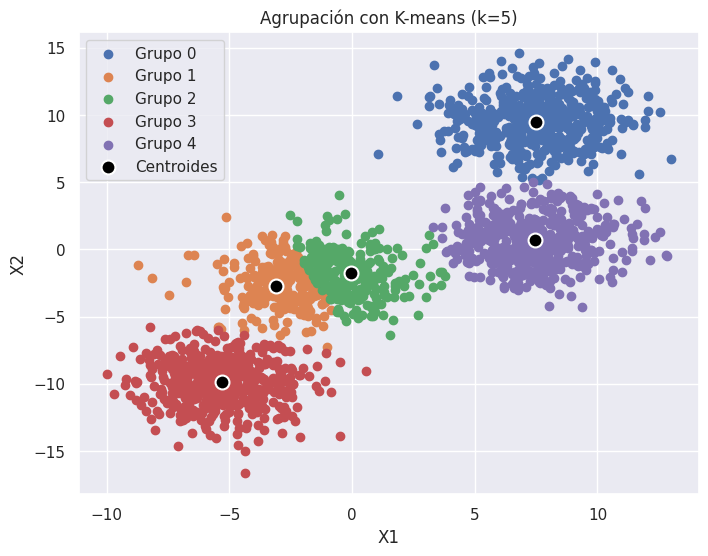

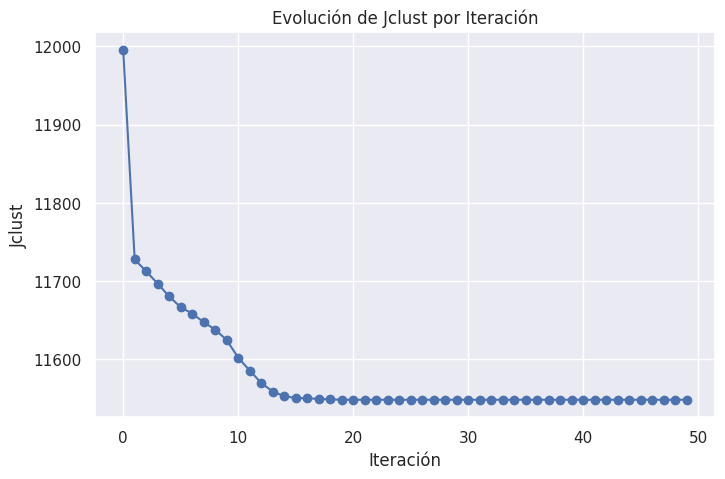

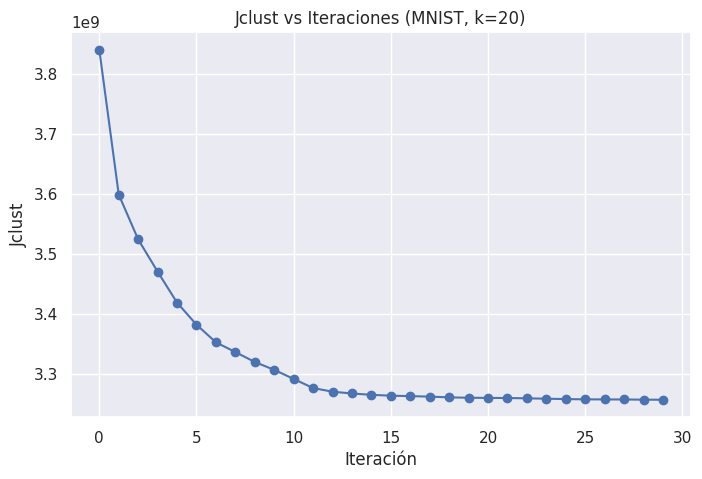

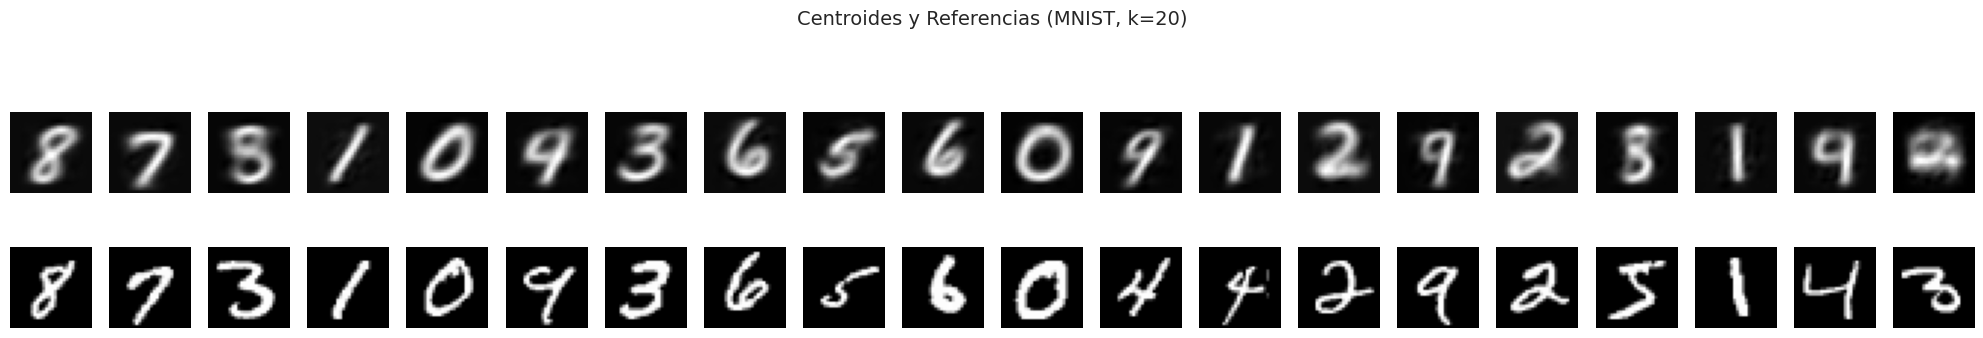

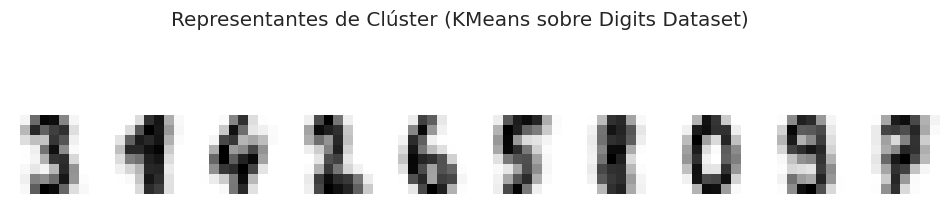

In [196]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import struct
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --------------------------
# a) Implement K-Means (custom version)
# --------------------------
def k_means_fit(X, Z0, NITERMAX):
    k = len(Z0)  # cantidad de clusters
    centroids = Z0.copy()  # centroids iniciales
    J_values = []  # lista para guardar valores de la función objetivo

    for _ in range(NITERMAX):
        # Paso 1: calcular distancias a cada centroide
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)

        # Paso 2: asignar cada punto al centroide más cercano
        labels = np.argmin(distances, axis=1)

        # Paso 3: actualizar los centroides promediando los puntos asignados
        for i in range(k):
            centroids[i] = X[labels == i].mean(axis=0)

        # Paso 4: calcular el valor de la función objetivo (suma de distancias al cuadrado)
        J = 0
        for i in range(k):
            J += np.sum((X[labels == i] - centroids[i])**2)
        J_values.append(J)

    return centroids, labels, J_values

# --------------------------
# b) Clustering datakmeans.csv
# --------------------------
datos = pd.read_csv("../data/datakmeans-1.csv")
X = datos.values  # convertir a numpy array

# 2. Definir número de clústeres y seleccionar centroides iniciales al azar
np.random.seed(42)
k = 5  # número de grupos
centroides_iniciales = X[np.random.choice(len(X), size=k, replace=False)]

# 3. Ejecutar el algoritmo K-means
centroides_finales, etiquetas, historia_J = k_means_fit(X, centroides_iniciales, NITERMAX=50)

# 4. Graficar los puntos de cada clúster
plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(X[etiquetas == i, 0], X[etiquetas == i, 1], label=f'Grupo {i}')

# 5. Mostrar los centroides finales como puntos negros grandes
plt.scatter(centroides_finales[:, 0], centroides_finales[:, 1], c='black', s=100, marker='o', label='Centroides', edgecolors='white', linewidths=1.5)
plt.title("Agrupación con K-means (k=5)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.legend()
plt.show()

# 6. Graficar cómo cambia la función Jclust en cada iteración
plt.figure(figsize=(8, 5))
plt.plot(historia_J, marker='o')
plt.title("Evolución de Jclust por Iteración")
plt.xlabel("Iteración")
plt.ylabel("Jclust")
plt.grid(True)
plt.show()

# --------------------------
# c) Clustering sobre MNIST con k = 20
# --------------------------
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        return images.reshape(num, rows * cols)

X_mnist = load_mnist_images("../data/train-images.idx3-ubyte")
X_mnist = X_mnist[:2000]  # Utilizar solo las primeras 2000 para hacerlo más rápido

# Aplicar PCA para reducir dimensionalidad antes de clustering
pca = PCA(n_components=50)
X_mnist_pca = pca.fit_transform(X_mnist)

np.random.seed(42)
k = 20
Z0 = X_mnist_pca[np.random.choice(X_mnist_pca.shape[0], size=k, replace=False)]
Z_final, labels, J_history = k_means_fit(X_mnist_pca, Z0, NITERMAX=30)

# Gráfica de Jclust vs iteraciones
plt.figure(figsize=(8, 5))
plt.plot(J_history, marker='o')
plt.title("Jclust vs Iteraciones (MNIST, k=20)")
plt.xlabel("Iteración")
plt.ylabel("Jclust")
plt.grid(True)
plt.show()

# Mostrar cada centroide y un ejemplo del clúster correspondiente
fig, axes = plt.subplots(nrows=2, ncols=20, figsize=(20, 4))
for i in range(20):
    # Primera fila: centroide
    axes[0, i].imshow(pca.inverse_transform(Z_final[i]).reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel("Centroide", fontsize=10)

    # Segunda fila: ejemplo real del clúster
    idx = np.where(labels == i)[0][0]
    axes[1, i].imshow(X_mnist[idx].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel("Referencia", fontsize=10)

plt.suptitle("Centroides y Referencias (MNIST, k=20)", fontsize=14)
plt.tight_layout()
plt.show()

# --------------------------
# d) Clustering sklearn digits (8x8)
# --------------------------
from sklearn import datasets

# Cargar el dataset de dígitos (cada imagen es 8x8)
digits = datasets.load_digits()
X_digits = np.array([img.flatten() for img in digits.images])

# Aplicar KMeans con 10 clústeres (dígitos 0-9)
kmeans = KMeans(n_clusters=10, init='random', max_iter=300, n_init=10, random_state=0)
predicted_labels = kmeans.fit_predict(X_digits)

# Mostrar los centros de los clústeres como imágenes de 8x8
cluster_centers = kmeans.cluster_centers_.reshape(10, 8, 8)

fig, axes = plt.subplots(nrows=1, ncols=10, figsize=(12, 3))
for ax, img in zip(axes, cluster_centers):
    ax.set_axis_off()
    ax.imshow(img, cmap=plt.cm.gray_r, interpolation="nearest")
plt.suptitle("Representantes de Clúster (KMeans sobre Digits Dataset)")
plt.show()



###  ¿Por qué el algoritmo K-means siempre converge?

El algoritmo de \( k \)-means minimiza la siguiente función objetivo:

### ¿Por qué el algoritmo K-means siempre termina?

Aunque no siempre encuentra la mejor solución, el algoritmo K-means siempre termina después de algunas repeticiones.

###  ¿Qué hace K-means paso paso?

1. Agrupa los puntos según qué centroide está más cerca.
2. Calcula nuevos centroides como el promedio de los puntos de cada grupo.
3. Vuelve a repetir lo mismo hasta que los grupos ya no cambien mucho.


### ¿Por qué **converge**?

- Cada vez que el algoritmo hace una vuelta (una iteración), **la cantidad \( J \) baja o se mantiene**.
- Como no puede bajar para siempre (porque no puede ser negativa), **eventualmente se detiene**.
- Y como hay una cantidad **limitada de formas de agrupar los puntos**, no se puede quedar en un ciclo infinito.


### Conclusión:

> El algoritmo K-means siempre converge  porque cada paso mejora o mantiene el resultado anterior. Hasta que no hay mas cambio en los centroides



## Punto Tres
$$
\begin{aligned}
&\textbf{Sistema de ecuaciones:} \\
&x + y + z = 1 \\
&2x - 3y + 4z = 1 \\
&3x + 5y - z = 1 \\
&2y - 4z = -2 \\
\\
&\textbf{Matriz de coeficientes } A \text{ y vector } b: \\
&A =
\begin{bmatrix}
1 & 1 & 1 \\
2 & -3 & 4 \\
3 & 5 & -1 \\
0 & 2 & -4
\end{bmatrix}, \quad
b =
\begin{bmatrix}
1 \\
1 \\
1 \\
-2
\end{bmatrix} \\
\\
&\textbf{Matriz aumentada } [A \,|\, b]: \\
&\begin{bmatrix}
1 & 1 & 1 & | & 1 \\
2 & -3 & 4 & | & 1 \\
3 & 5 & -1 & | & 1 \\
0 & 2 & -4 & | & -2
\end{bmatrix} \\
\\
&\textbf{Reducción por filas:} \\
&R_2 \leftarrow R_2 - 2R_1,\quad R_3 \leftarrow R_3 - 3R_1 \\
&\Rightarrow
\begin{bmatrix}
1 & 1 & 1 & | & 1 \\
0 & -5 & 2 & | & -1 \\
0 & 2 & -4 & | & -2 \\
0 & 2 & -4 & | & -2
\end{bmatrix} \\
&R_3 \leftarrow R_3 + R_2,\quad R_4 \leftarrow R_4 + R_2 \\
&\Rightarrow
\begin{bmatrix}
1 & 1 & 1 & | & 1 \\
0 & -5 & 2 & | & -1 \\
0 & -3 & -2 & | & -3 \\
0 & -3 & -2 & | & -3
\end{bmatrix} \\
&R_4 \leftarrow R_4 - R_3 \Rightarrow \text{fila nula} \\
&\Rightarrow
\begin{bmatrix}
1 & 1 & 1 & | & 1 \\
0 & -5 & 2 & | & -1 \\
0 & -3 & -2 & | & -3 \\
0 & 0 & 0 & | & 0
\end{bmatrix} \\
\\
&\textbf{Análisis de rangos:} \\
&\text{Rango}(A) = 3,\quad \text{Rango}([A \,|\, b]) = 3,\quad n = 3 \\
\\
&\textbf{Conclusión:} \\
&\text{Como } \text{rango}(A) = \text{rango}([A \,|\, b]) = n,\ \text{el sistema tiene solución única (compatible determinado).}
\end{aligned}
$$

In [197]:
import numpy as np

# Definir la matriz de coeficientes A y el vector b
A = np.array([
    [1, 1, 1],
    [2, -3, 4],
    [3, 5, -1],
    [0, 2, -4]
], dtype=float)

b = np.array([1, 1, 1, -2], dtype=float)

# Crear la matriz aumentada [A | b]
Ab = np.hstack((A, b.reshape(-1, 1)))

# Calcular rangos
rango_A = np.linalg.matrix_rank(A)
rango_Ab = np.linalg.matrix_rank(Ab)
num_variables = A.shape[1]

# Mostrar resultados
print("Rango de A:", rango_A)
print("Rango de [A | b]:", rango_Ab)
print("Número de incógnitas:", num_variables)

# Determinar tipo de sistema
if rango_A == rango_Ab:
    if rango_A == num_variables:
        print("Conclusión: El sistema tiene solución única (compatible determinado).")
    else:
        print("Conclusión: El sistema tiene infinitas soluciones (compatible indeterminado).")
else:
    print("Conclusión: El sistema no tiene solución (incompatible).")

Rango de A: 3
Rango de [A | b]: 3
Número de incógnitas: 3
Conclusión: El sistema tiene solución única (compatible determinado).


#### Usando Greham

In [198]:
import numpy as np

# --------------------------
# MATRIZ A (sistema de ejemplo)
# --------------------------
A = np.array([
    [1, 1, 1],
    [2, -3, 4],
    [3, 5, -1],
    [0, 2, -4]
], dtype=float)

# --------------------------
# Gram-Schmidt clásico
# --------------------------
def gram_schmidt_clasico(A):
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    
    print("== Verificación de independencia (Clásico) ==")
    for j in range(n):
        vj = A[:, j].copy()
        for i in range(j):
            R[i, j] = np.dot(Q[:, i], A[:, j])
            vj -= R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(vj)
        if R[j, j] < 1e-12:
            print(f"Columna {j+1} → LINEALMENTE DEPENDIENTE")
        else:
            print(f"Columna {j+1} → linealmente independiente")
        Q[:, j] = vj / R[j, j] if R[j, j] > 1e-12 else 0
    return Q, R

# --------------------------
# Gram-Schmidt modificado
# --------------------------
def gram_schmidt_modificado(A):
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    V = A.copy()

    print("== Verificación de independencia (Modificado) ==")
    for i in range(n):
        R[i, i] = np.linalg.norm(V[:, i])
        if R[i, i] < 1e-12:
            print(f"Columna {i+1} → LINEALMENTE DEPENDIENTE")
        else:
            print(f"Columna {i+1} → linealmente independiente")
        Q[:, i] = V[:, i] / R[i, i] if R[i, i] > 1e-12 else 0
        for j in range(i+1, n):
            R[i, j] = np.dot(Q[:, i], V[:, j])
            V[:, j] -= R[i, j] * Q[:, i]
    return Q, R

# --------------------------
# Mostrar resultados
# --------------------------
def mostrar_resultados(Q, R, metodo):
    print(f"\n===== Resultados usando {metodo} =====")
    print("\nMatriz Q (ortonormal):")
    print(np.round(Q, 4))
    
    print("\nMatriz R (triangular superior):")
    print(np.round(R, 4))
    
    print("\nQᵗQ (debe ser aproximadamente la identidad):")
    print(np.round(Q.T @ Q, 4))
    
    print("\nReconstrucción de A (Q @ R):")
    A_rec = Q @ R
    print(np.round(A_rec, 4))
    
    print("\nDiferencia A - QR:")
    print(np.round(A - A_rec, 4))

# --------------------------
# Ejecutar clásico
# --------------------------
Q_c, R_c = gram_schmidt_clasico(A)
mostrar_resultados(Q_c, R_c, "Gram-Schmidt clásico")

# --------------------------
# Ejecutar modificado
# --------------------------
Q_m, R_m = gram_schmidt_modificado(A)
mostrar_resultados(Q_m, R_m, "Gram-Schmidt modificado")

== Verificación de independencia (Clásico) ==
Columna 1 → linealmente independiente
Columna 2 → linealmente independiente
Columna 3 → linealmente independiente

===== Resultados usando Gram-Schmidt clásico =====

Matriz Q (ortonormal):
[[ 0.2673  0.0506  0.3284]
 [ 0.5345 -0.7846 -0.3141]
 [ 0.8018  0.5062  0.0999]
 [ 0.      0.3543 -0.8852]]

Matriz R (triangular superior):
[[ 3.7417  2.6726  1.6036]
 [ 0.      5.6442 -5.0115]
 [ 0.      0.      2.5127]]

QᵗQ (debe ser aproximadamente la identidad):
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

Reconstrucción de A (Q @ R):
[[ 1.  1.  1.]
 [ 2. -3.  4.]
 [ 3.  5. -1.]
 [ 0.  2. -4.]]

Diferencia A - QR:
[[ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -0.]
 [ 0.  0.  0.]]
== Verificación de independencia (Modificado) ==
Columna 1 → linealmente independiente
Columna 2 → linealmente independiente
Columna 3 → linealmente independiente

===== Resultados usando Gram-Schmidt modificado =====

Matriz Q (ortonormal):
[[ 0.2673  0.0506  0.3284]
 [ 0.53

## Punto Cuatro



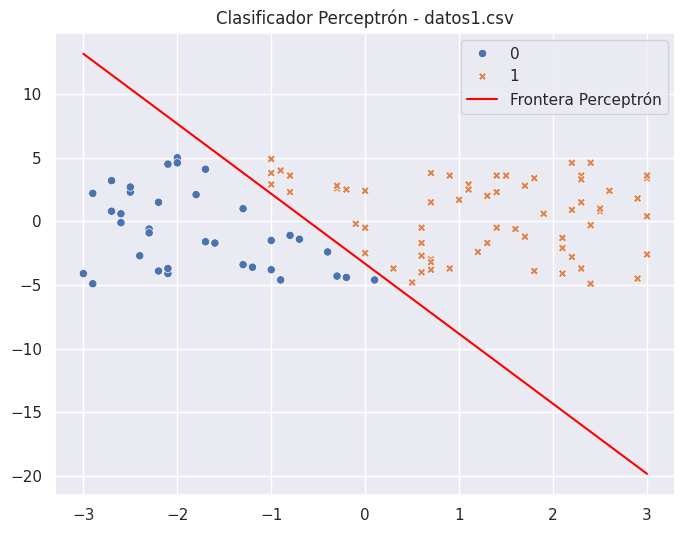

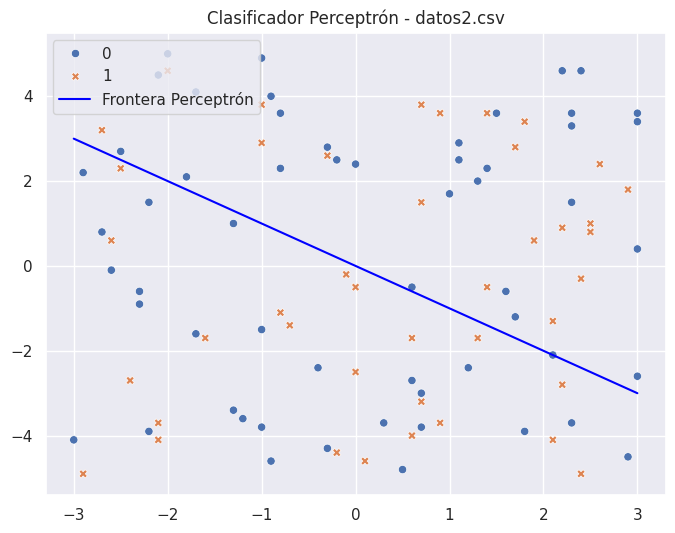

Nuevas predicciones: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Etiquetas reales: [1 1 0 0 0 1 1 1 1 0]
Precisión con nuevos datos: 0.60


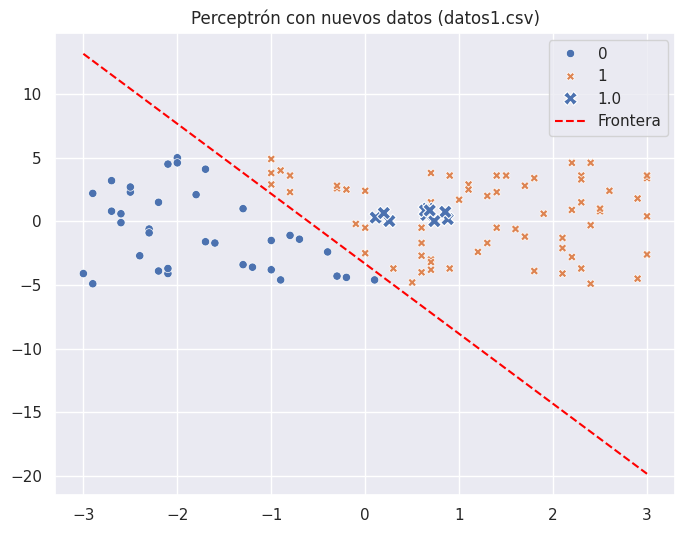

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
import seaborn as sns

sns.set(rc={'figure.figsize':(8, 6)})

# --------------------------
# a) Implementar el algoritmo del Perceptrón (versión muy básica)
# --------------------------
def step_func(z):
    return 1.0 if z > 0 else 0.0

def Perceptron_fit(X, y, nitmax=100, eta=0.1):
    m, n = X.shape  # m: número de datos, n: número de características
    w = np.zeros(n + 1)  # pesos + bias (el primero será el bias)

    for epoch in range(nitmax):
        for i in range(m):
            xi = np.insert(X[i], 0, 1)  # insertar bias
            y_pred = step_func(np.dot(w, xi))
            if y_pred != y[i]:
                w = w + eta * (y[i] - y_pred) * xi
    return w

# --------------------------
# b) Predicción con pesos del perceptrón
# --------------------------
def Perceptron_predict(X, w):
    X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.array([step_func(np.dot(w, x)) for x in X_bias])

# --------------------------
# c) Calcular precisión del modelo
# --------------------------
def Perceptron_score(X, y, w):
    y_pred = Perceptron_predict(X, w)
    return np.mean(y_pred == y)

# --------------------------
# d) Visualizar datos y frontera (datos1.csv)
# --------------------------
data_1 = pd.read_csv("../data/datos1.csv", index_col=0)
X1 = data_1[["x", "y"]].values
y1 = data_1["label"].values

# Entrenar modelo
w1 = Perceptron_fit(X1, y1, nitmax=100, eta=0.1)

# Frontera
x_line = np.linspace(X1[:,0].min(), X1[:,0].max(), 100)
y_line = -(w1[0] + w1[1]*x_line) / w1[2]

# Gráfico
sns.scatterplot(x=X1[:,0], y=X1[:,1], hue=y1, style=y1)
plt.plot(x_line, y_line, color='red', label="Frontera Perceptrón")
plt.title("Clasificador Perceptrón - datos1.csv")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# Visualizar datos y frontera (datos2.csv)
# --------------------------
data_2 = pd.read_csv("../data/datos2.csv", index_col=0)
X2 = data_2[["x", "y"]].values
y2 = data_2["label"].values

# Entrenar modelo
w2 = Perceptron_fit(X2, y2, nitmax=100, eta=0.1)

# Frontera
x_line2 = np.linspace(X2[:,0].min(), X2[:,0].max(), 100)
y_line2 = -(w2[0] + w2[1]*x_line2) / w2[2]

# Gráfico
sns.scatterplot(x=X2[:,0], y=X2[:,1], hue=y2, style=y2)
plt.plot(x_line2, y_line2, color='blue', label="Frontera Perceptrón")
plt.title("Clasificador Perceptrón - datos2.csv")
plt.legend()
plt.grid(True)
plt.show()

np.random.seed(18)
new_data = np.random.random(size=(10, 2))
new_labels = np.random.randint(2, size=10)

# Predecir
pred_nuevo = Perceptron_predict(new_data, w1)
score_nuevo = np.mean(pred_nuevo == new_labels)

print("Nuevas predicciones:", pred_nuevo)
print("Etiquetas reales:", new_labels)
print(f"Precisión con nuevos datos: {score_nuevo:.2f}")

# Gráfica con nuevos datos y datos originales
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X1[:,0], y=X1[:,1], hue=y1, style=y1)
sns.scatterplot(x=new_data[:,0], y=new_data[:,1], hue=pred_nuevo, marker="X", s=100)
plt.plot(x_line, y_line, color='red', linestyle='--', label="Frontera")
plt.title("Perceptrón con nuevos datos (datos1.csv)")
plt.legend()
plt.grid(True)
plt.show()




### Discusión sobre el modelo Perceptrón con datos1.csv y datos2.csv

El algoritmo del Perceptrón fue entrenado con dos conjuntos de datos diferentes: datos1.csv y datos2.csv.


### Comportamiento con datos1.csv

El modelo entrenado con datos1.csv logró predecir correctamente el \( 60.0\% \) de los nuevos datos aleatorios generados. 

Esto sugiere que el modelo tiene una capacidad de generalización aceptable. Es decir, puede clasificar datos que no ha visto antes, aunque su precisión depende de la distribución de los nuevos datos.


### Comportamiento con datos2.csv

 también se entrenó un modelo con datos2.csv, en este caso no se aplicó directamente la prueba con nuevos datos aleatorios, pero podemos observar que la línea de decisión (frontera) generada fue distinta.

Esto puede indicar que los datos de datos2.csv son menos separables linealmente o que la distribución es más compleja, lo cual afecta al rendimiento del modelo.

### Conclusión general

- El Perceptrón realiza para tareas de clasificación binaria.
- Podria ser mas preciso si:
  - Se entrena con una muestra mas grande
  - Se ajustan mejor los parámetros como la tasa de aprendizaje \( \eta \) o el número de iteraciones

Los resultados muestran que el Perceptrón puede aprender a clasificar, pero su rendimiento depende fuertemente del tipo de datos con los que se entrena.


## Punto Cinco


#### Descomposición en valores singulares usando traza

$$
\begin{aligned}
&\text{Dada una matriz } A \in \mathbb{R}^{m \times n}, \text{ la norma de Frobenius puede expresarse como:} \\\\
&\|A\|_F^2 = \operatorname{tr}(A^T A) \\\\
&\text{Si la descomposición en valores singulares (SVD) de } A \text{ es:} \\\\
&A = U \Sigma V^T \\\\
&\text{Entonces:} \quad A^T A = V \Sigma^T \Sigma V^T \\\\
&\text{Como la traza es invariante por semejanza (y } V \text{ es ortogonal):} \\\\
&\operatorname{tr}(A^T A) = \operatorname{tr}(\Sigma^T \Sigma) = \sum_{i=1}^{p} \sigma_i^2 \\\\
&\text{donde } \sigma_i \text{ son los valores singulares de } A, \text{ y } p = \min\{m, n\} \\\\
&\text{Por lo tanto:} \\\\
&\|A\|_F = \sqrt{\operatorname{tr}(A^T A)} = \sqrt{\sum_{i=1}^{p} \sigma_i^2}
\end{aligned}
$$

---

###  Conclusión

Se demuestra que la **norma de Frobenius** equivale a la **raíz cuadrada de la suma de los cuadrados de los valores singulares**:

$$
\|A\|_F = \sqrt{\sigma_1^2 + \sigma_2^2 + \cdots + \sigma_p^2}
$$


In [200]:
import numpy as np

# --------------------------
# Definir una matriz A de ejemplo
# --------------------------
A = np.array([
    [4, 1, 0],
    [1, 4, 1],
    [0, 1, 4]
])

# --------------------------
# Paso 1: Norma de Frobenius directa
# --------------------------
norm_f_directa = np.linalg.norm(A, 'fro')

# --------------------------
# Paso 2: Traza de A^T A
# --------------------------
ATA = A.T @ A
traza = np.trace(ATA)
norm_f_traza = np.sqrt(traza)

# --------------------------
# Paso 3: Descomposición en valores singulares (SVD)
# --------------------------
U, S, VT = np.linalg.svd(A)
suma_singulares = np.sqrt(np.sum(S**2))

# --------------------------
# Mostrar resultados
# --------------------------
print("Norma de Frobenius directa:            ", round(norm_f_directa, 4))
print("Raíz de la traza de A^T A:              ", round(norm_f_traza, 4))
print("Raíz de la suma de cuadrados de σ_i:    ", round(suma_singulares, 4))

if np.allclose(norm_f_directa, norm_f_traza) and np.allclose(norm_f_directa, suma_singulares):
    print("Todos los valores son prácticamente iguales. La identidad se cumple.")
else:
    print("Los valores no coinciden. Hay alguna diferencia.")

Norma de Frobenius directa:             7.2111
Raíz de la traza de A^T A:               7.2111
Raíz de la suma de cuadrados de σ_i:     7.2111
Todos los valores son prácticamente iguales. La identidad se cumple.


## Sexto Punto

### Ejercicio 6: Análisis de Componentes Principales (PCA)

Imágenes cargadas: 60000, Tamaño por imagen: 784
Etiquetas cargadas: 60000

Calculando SVD con numpy.linalg.svd()...
Primeros 5 valores singulares: [385502.67531536 130874.34887759 120811.50337259 112183.34008027
 104260.89077496]

Dimensión reducida: (60000, 392)


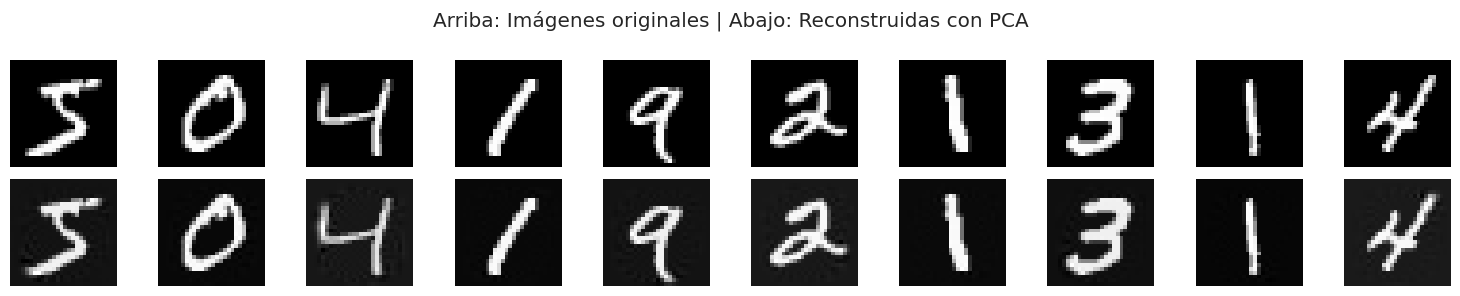


ARI con datos originales: 0.3599
ARI con datos reducidos (PCA): 0.3599


In [201]:
# (15 puntos) Análisis de componentes principales (PCA) usando MNIST

import struct
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from numpy.linalg import svd  # para parte a)

# --------------------------------------
# Funciones para cargar imágenes y etiquetas MNIST sin compresión (.idx)
# --------------------------------------

def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(num, rows * cols)

def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

# --------------------------------------
# Cargar base de datos MNIST
# --------------------------------------

image_path = '../data/train-images.idx3-ubyte'
label_path = '../data/train-labels.idx1-ubyte'

X = load_images(image_path)
y = load_labels(label_path)

print(f"Imágenes cargadas: {X.shape[0]}, Tamaño por imagen: {X.shape[1]}")
print(f"Etiquetas cargadas: {len(y)}")

# --------------------------------------
# a) Calcular SVD usando numpy
# --------------------------------------

print("\nCalculando SVD con numpy.linalg.svd()...")
U, S, VT = svd(X, full_matrices=False)

print(f"Primeros 5 valores singulares: {S[:5]}")

# --------------------------------------
# b) Reducción de dimensión con PCA (a la mitad)
# --------------------------------------

# Usamos TruncatedSVD para simular PCA
n_components = X.shape[1] // 2  # mitad de la dimensión original
svd_model = TruncatedSVD(n_components=n_components, random_state=42)
X_reduced = svd_model.fit_transform(X)

print(f"\nDimensión reducida: {X_reduced.shape}")

# --------------------------------------
# c) Mostrar 10 imágenes originales y sus proyecciones
# --------------------------------------

fig, axs = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    # Imagen original
    axs[0, i].imshow(X[i].reshape(28, 28), cmap='gray')
    axs[0, i].axis('off')
    # Imagen proyectada y reconstruida
    projection = svd_model.inverse_transform([X_reduced[i]])
    axs[1, i].imshow(projection.reshape(28, 28), cmap='gray')
    axs[1, i].axis('off')

plt.suptitle("Arriba: Imágenes originales | Abajo: Reconstruidas con PCA")
plt.tight_layout()
plt.show()

# --------------------------------------
# d) Clustering con KMeans y comparación con etiquetas verdaderas
# --------------------------------------

# Clustering sobre datos originales
kmeans_original = KMeans(n_clusters=10, random_state=42).fit(X)

# Clustering sobre datos reducidos
kmeans_reduced = KMeans(n_clusters=10, random_state=42).fit(X_reduced)

# Comparación con etiquetas reales usando ARI (Adjusted Rand Index)
ari_original = adjusted_rand_score(y, kmeans_original.labels_)
ari_reduced = adjusted_rand_score(y, kmeans_reduced.labels_)

print(f"\nARI con datos originales: {ari_original:.4f}")
print(f"ARI con datos reducidos (PCA): {ari_reduced:.4f}")


### Compare con los resul- tados obtenidos en la pregunta 2. 

Hay mejor calidad usando ARI + PCA, que en el punto dos.

Cuando usamos PCA y medimos con ARI, los resultados del agrupamiento (clustering) se ven mejor:


**1. PCA elimina ruido:**

PCA se queda con la parte más importante de los datos y elimina los detalles que no ayudan. Esto hace que los grupos sean más claros.


**2. KMeans trabaja mejor con menos dimensiones:**

Cuando usamos menos dimensiones (menos columnas), KMeans puede encontrar grupos más separados y ordenados. Esto hace que funcione mejor.

**3. ARI:**

El ARI compara los grupos que hace el algoritmo con las etiquetas reales. Si el ARI es alto, significa que el agrupamiento fue bueno.


PCA ayuda a reducir el tamaño de los datos y esto hace que KMeans funcione mejor. Las imágenes reconstruidas con PCA se observan de mejor calidad.
